# MetalDAM Semantic Segmentation 

## – Step 1: File Pairing & Train/Val Split

In [8]:
from google.colab import drive
from pathlib import Path
from sklearn.model_selection import train_test_split

### ──Paths──────────────────────────────────────────────────────────────

In [10]:
drive.mount("/content/drive")

Mounted at /content/drive


In [11]:
IMAGES_DIR = Path("/content/drive/MyDrive/MetalDAM/images")
LABELS_DIR = Path("/content/drive/MyDrive/MetalDAM/coloured_labels")

RANDOM_STATE = 42
VAL_RATIO = 0.20

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
LABEL_EXTS = {".png", ".tif", ".tiff", ".bmp"}

In [12]:
def match_file_pairs(images_dir: Path, labels_dir: Path) -> list[tuple[Path, Path]]:
    """
    Pair each image with its corresponding colour-label mask.

    Matches by stem (filename without extension).
    Raises FileNotFoundError if any image lacks a matching mask.
    """
    # Collect all valid image files
    image_paths = sorted(
        p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS
    )
    if not image_paths:
        raise FileNotFoundError(f"No image files found in {images_dir}")

    # Build a stem -> path lookup for labels
    label_map = {
        p.stem: p for p in labels_dir.iterdir() if p.suffix.lower() in LABEL_EXTS
    }

    pairs = []
    missing = []

    for img_path in image_paths:
        if img_path.stem in label_map:
            pairs.append((img_path, label_map[img_path.stem]))
        else:
            missing.append(img_path.name)

    if missing:
        raise FileNotFoundError(
            f"{len(missing)} image(s) have no matching mask:\n"
            + "\n".join(f"  - {name}" for name in missing)
        )

    return pairs

### ──Main───────────────────────────────────────────────────────────────


In [13]:
if __name__ == "__main__":
    pairs = match_file_pairs(IMAGES_DIR, LABELS_DIR)
    print(f"Total paired samples: {len(pairs)}")

    train_pairs, val_pairs = train_test_split(
        pairs,
        test_size=VAL_RATIO,
        random_state=RANDOM_STATE,
    )

    print(f"Train: {len(train_pairs)}")
    print(f"Val:   {len(val_pairs)}")

    # Quick sanity check
    print(f"\nSample train pair: {train_pairs[0][0].name} ↔ {train_pairs[0][1].name}")
    print(f"Sample val pair:   {val_pairs[0][0].name} ↔ {val_pairs[0][1].name}")

Total paired samples: 42
Train: 33
Val:   9

Sample train pair: micrograph14.jpg ↔ micrograph14.png
Sample val pair:   micrograph31.jpg ↔ micrograph31.png


## – Step 2: Loading & Verification

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

In [15]:
# ── Class colour map (class 0 = black, 1–3 = distinct colours) ─────────
CLASS_CMAP = ListedColormap([
    [0.0, 0.0, 0.0],   # 0 → black
    [0.2, 0.6, 1.0],   # 1 → blue
    [1.0, 0.8, 0.0],   # 2 → amber
    [0.9, 0.2, 0.3],   # 3 → red
])

In [18]:
def load_pair(image_path: Path, mask_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """
    Load an image as grayscale and its mask with exact pixel values preserved.
    If the image is taller than the mask (SEM info bar), the bottom rows are
    cropped automatically.

    Returns
    -------
    image : np.ndarray, shape (H, W), dtype uint8
    mask  : np.ndarray, shape (H, W) or (H, W, C), dtype uint8
    """
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise FileNotFoundError(f"Could not load mask: {mask_path}")

    img_h, img_w = image.shape[:2]
    msk_h, msk_w = mask.shape[:2]

    # Widths must match
    if img_w != msk_w:
        raise ValueError(
            f"Width mismatch: image {img_w} vs mask {msk_w} for {image_path.name}"
        )

    # Crop bottom of image (SEM info bar) if taller than mask
    if img_h > msk_h:
        cropped = img_h - msk_h
        print(f"  ↳ Cropping {cropped}px from bottom of {image_path.name} (SEM bar)")
        image = image[:msk_h, :]
    elif img_h < msk_h:
        raise ValueError(
            f"Image is shorter than mask: {img_h} vs {msk_h} for {image_path.name}"
        )

    return image, mask


def visualize_sample(image: np.ndarray, mask: np.ndarray, title: str = "") -> None:
    """
    Plot a grayscale image and its class mask side-by-side.

    If the mask is single-channel with values in {0,1,2,3}, it is displayed
    with CLASS_CMAP. Otherwise it is shown as-is (RGB) so you can inspect
    the raw coloured labels.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Image
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Grayscale image")
    axes[0].axis("off")

    # Mask
    if mask.ndim == 2:
        axes[1].imshow(mask, cmap=CLASS_CMAP, vmin=0, vmax=3, interpolation="nearest")
        axes[1].set_title("Class mask (mapped)")
    else:
        # RGB / multi-channel → show as-is for inspection
        display = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB) if mask.shape[2] == 3 else mask
        axes[1].imshow(display, interpolation="nearest")
        axes[1].set_title("Colour label (raw RGB)")

    if title:
        fig.suptitle(title, fontsize=13)

    plt.tight_layout()
    plt.show()

### ──Quick_test─────────────────────────────────────────────────────────

  ↳ Cropping 65px from bottom of micrograph14.jpg (SEM bar)
Image  – shape: (703, 1024), dtype: uint8
Mask   – shape: (703, 1024, 3), dtype: uint8
Mask   – unique values: [[  0   0 255]
 [  0 255  43]
 [255   0 128]
 [255   0 255]]


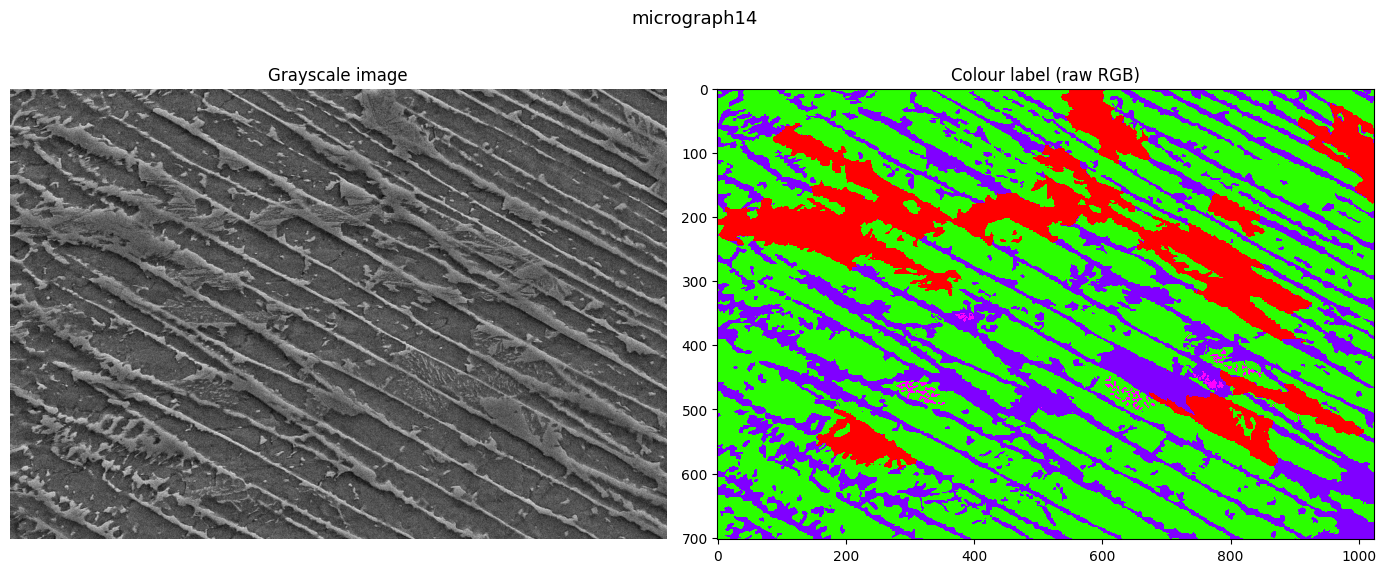

In [19]:
if __name__ == "__main__":
    # Uses train_pairs from Step 1
    img_path, msk_path = train_pairs[0]

    image, mask = load_pair(img_path, msk_path)

    print(f"Image  – shape: {image.shape}, dtype: {image.dtype}")
    print(f"Mask   – shape: {mask.shape}, dtype: {mask.dtype}")
    print(f"Mask   – unique values: {np.unique(mask.reshape(-1, mask.shape[-1]) if mask.ndim == 3 else mask, axis=0)}")

    visualize_sample(image, mask, title=img_path.stem)

## – Step 3: Validation Set Preprocessing & Save

In [20]:
import albumentations as A
from pathlib import Path
from tqdm import tqdm

### ──Output_directories_(Google_Drive)──────────────────────────────────


In [21]:
OUTPUT_BASE = Path("/content/drive/MyDrive/MetalDAM/ready_for_training")
VAL_IMG_DIR = OUTPUT_BASE / "val" / "images"
VAL_MSK_DIR = OUTPUT_BASE / "val" / "labels"

In [22]:
def create_output_dirs(*dirs: Path) -> None:
    """Create output directories if they don't exist."""
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        print(f"  ✔ {d}")

### ──Validation_augmentation:deterministic_centre_crop_only────────────


In [23]:
val_transform = A.Compose([
    A.CenterCrop(height=256, width=256),
])

In [24]:
def process_and_save_pairs(
    pairs: list[tuple[Path, Path]],
    out_img_dir: Path,
    out_msk_dir: Path,
    transform: A.Compose,
) -> None:
    """
    Load each pair, apply transform, and save to disk.
    Masks are saved as lossless PNGs to preserve exact pixel values.
    """
    for img_path, msk_path in tqdm(pairs, desc="Processing"):
        image, mask = load_pair(img_path, msk_path)

        # albumentations expects image & mask together so spatial transforms stay in sync
        augmented = transform(image=image, mask=mask)
        crop_img = augmented["image"]
        crop_msk = augmented["mask"]

        stem = img_path.stem

        # Save image as lossless PNG
        cv2.imwrite(
            str(out_img_dir / f"{stem}.png"),
            crop_img,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],  # 0–9, 3 = good speed/size balance
        )

        # Save mask as lossless PNG (critical: preserves exact class IDs)
        cv2.imwrite(
            str(out_msk_dir / f"{stem}.png"),
            crop_msk,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],
        )

Creating output directories…
  ✔ /content/drive/MyDrive/MetalDAM/ready_for_training/val/images
  ✔ /content/drive/MyDrive/MetalDAM/ready_for_training/val/labels

Processing 9 validation pairs…


Processing:  11%|█         | 1/9 [00:00<00:07,  1.05it/s]

  ↳ Cropping 65px from bottom of micrograph31.jpg (SEM bar)


Processing:  22%|██▏       | 2/9 [00:01<00:04,  1.46it/s]

  ↳ Cropping 65px from bottom of micrograph20.jpg (SEM bar)


...

  ↳ Cropping 65px from bottom of micrograph26.jpg (SEM bar)


Processing:  89%|████████▉ | 8/9 [00:05<00:00,  1.51it/s]

  ↳ Cropping 65px from bottom of micrograph35.jpg (SEM bar)


Processing: 100%|██████████| 9/9 [00:06<00:00,  1.38it/s]

  ↳ Cropping 65px from bottom of micrograph36.jpg (SEM bar)

Saved: 9 images, 9 masks
Sample image shape: (256, 256)
Sample mask  shape: (256, 256, 3)
Sample mask  unique: [[  0   0 255]
 [  0 255  43]
 [255   0 128]]


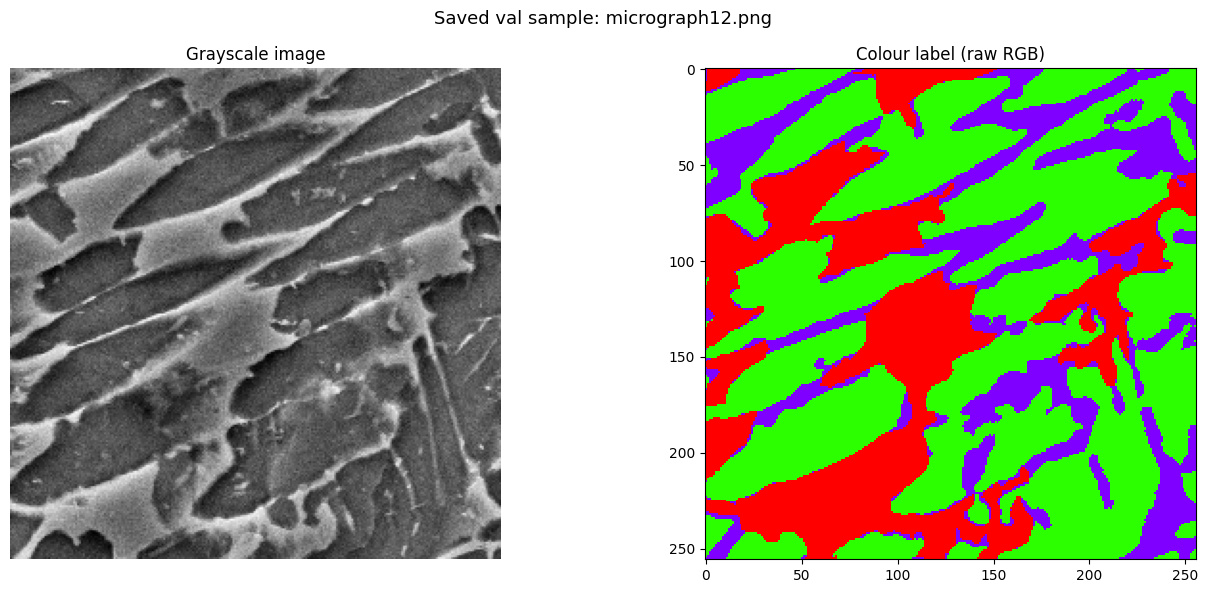

In [25]:
if __name__ == "__main__":
    print("Creating output directories…")
    create_output_dirs(VAL_IMG_DIR, VAL_MSK_DIR)

    print(f"\nProcessing {len(val_pairs)} validation pairs…")
    process_and_save_pairs(val_pairs, VAL_IMG_DIR, VAL_MSK_DIR, val_transform)

    # Sanity check: reload one saved pair and verify
    saved_imgs = sorted(VAL_IMG_DIR.glob("*.png"))
    saved_msks = sorted(VAL_MSK_DIR.glob("*.png"))
    print(f"\nSaved: {len(saved_imgs)} images, {len(saved_msks)} masks")

    sample_img = cv2.imread(str(saved_imgs[0]), cv2.IMREAD_GRAYSCALE)
    sample_msk = cv2.imread(str(saved_msks[0]), cv2.IMREAD_UNCHANGED)
    print(f"Sample image shape: {sample_img.shape}")
    print(f"Sample mask  shape: {sample_msk.shape}")
    print(f"Sample mask  unique: {np.unique(sample_msk.reshape(-1, sample_msk.shape[-1]) if sample_msk.ndim == 3 else sample_msk, axis=0)}")

    visualize_sample(sample_img, sample_msk, title=f"Saved val sample: {saved_imgs[0].name}")

## – Step 4: Training Set Augmentation & Save

In [30]:
import albumentations as A

### ──Output_directories─────────────────────────────────────────────────


In [31]:
TRAIN_IMG_DIR = OUTPUT_BASE / "train" / "images"
TRAIN_MSK_DIR = OUTPUT_BASE / "train" / "labels"

NUM_AUGMENTATIONS = 5

### ──Training_augmentation_pipeline─────────────────────────────────────

In [32]:
train_transform = A.Compose([
    # Spatial (applied to image + mask)
    A.RandomCrop(height=256, width=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GridDistortion(
        num_steps=5,
        distort_limit=0.3,
        interpolation=cv2.INTER_LINEAR,          # image
        border_mode=cv2.BORDER_REFLECT_101,
        mask_interpolation=cv2.INTER_NEAREST,     # mask: preserve class IDs
        p=0.4,
    ),
    A.ElasticTransform(
        alpha=80,
        sigma=10,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        mask_interpolation=cv2.INTER_NEAREST,
        p=0.3,
    ),
    # Pixel-level (image only, masks untouched automatically)
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5,
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.3,
    ),
])

In [33]:
def augment_and_save_pairs(
    pairs: list[tuple[Path, Path]],
    out_img_dir: Path,
    out_msk_dir: Path,
    transform: A.Compose,
    n_augments: int,
) -> None:
    """
    For each pair, generate n_augments augmented versions and save to disk.
    Files are named {stem}_aug{i}.png.
    Masks are saved as lossless PNGs to preserve exact class IDs.
    """
    total = len(pairs) * n_augments
    pbar = tqdm(total=total, desc="Augmenting train")

    for img_path, msk_path in pairs:
        image, mask = load_pair(img_path, msk_path)
        stem = img_path.stem

        for i in range(n_augments):
            augmented = transform(image=image, mask=mask)
            aug_img = augmented["image"]
            aug_msk = augmented["mask"]

            fname = f"{stem}_aug{i}.png"

            cv2.imwrite(
                str(out_img_dir / fname),
                aug_img,
                [cv2.IMWRITE_PNG_COMPRESSION, 3],
            )
            cv2.imwrite(
                str(out_msk_dir / fname),
                aug_msk,
                [cv2.IMWRITE_PNG_COMPRESSION, 3],
            )
            pbar.update(1)

    pbar.close()

Creating output directories…
  ✔ /content/drive/MyDrive/MetalDAM/ready_for_training/train/images
  ✔ /content/drive/MyDrive/MetalDAM/ready_for_training/train/labels

Augmenting 33 training pairs × 5 = 165 samples…


Augmenting train:   1%|          | 2/165 [00:00<00:10, 16.22it/s]

  ↳ Cropping 65px from bottom of micrograph14.jpg (SEM bar)


Augmenting train:   5%|▌         | 9/165 [00:01<00:18,  8.60it/s]

  ↳ Cropping 65px from bottom of micrograph33.jpg (SEM bar)


...

  ↳ Cropping 65px from bottom of micrograph21.jpg (SEM bar)


Augmenting train:  95%|█████████▌| 157/165 [00:27<00:01,  5.34it/s]

  ↳ Cropping 65px from bottom of micrograph34.jpg (SEM bar)


Augmenting train: 100%|██████████| 165/165 [00:28<00:00,  5.83it/s]

  ↳ Cropping 65px from bottom of micrograph6.jpg (SEM bar)

Saved: 165 images, 165 masks


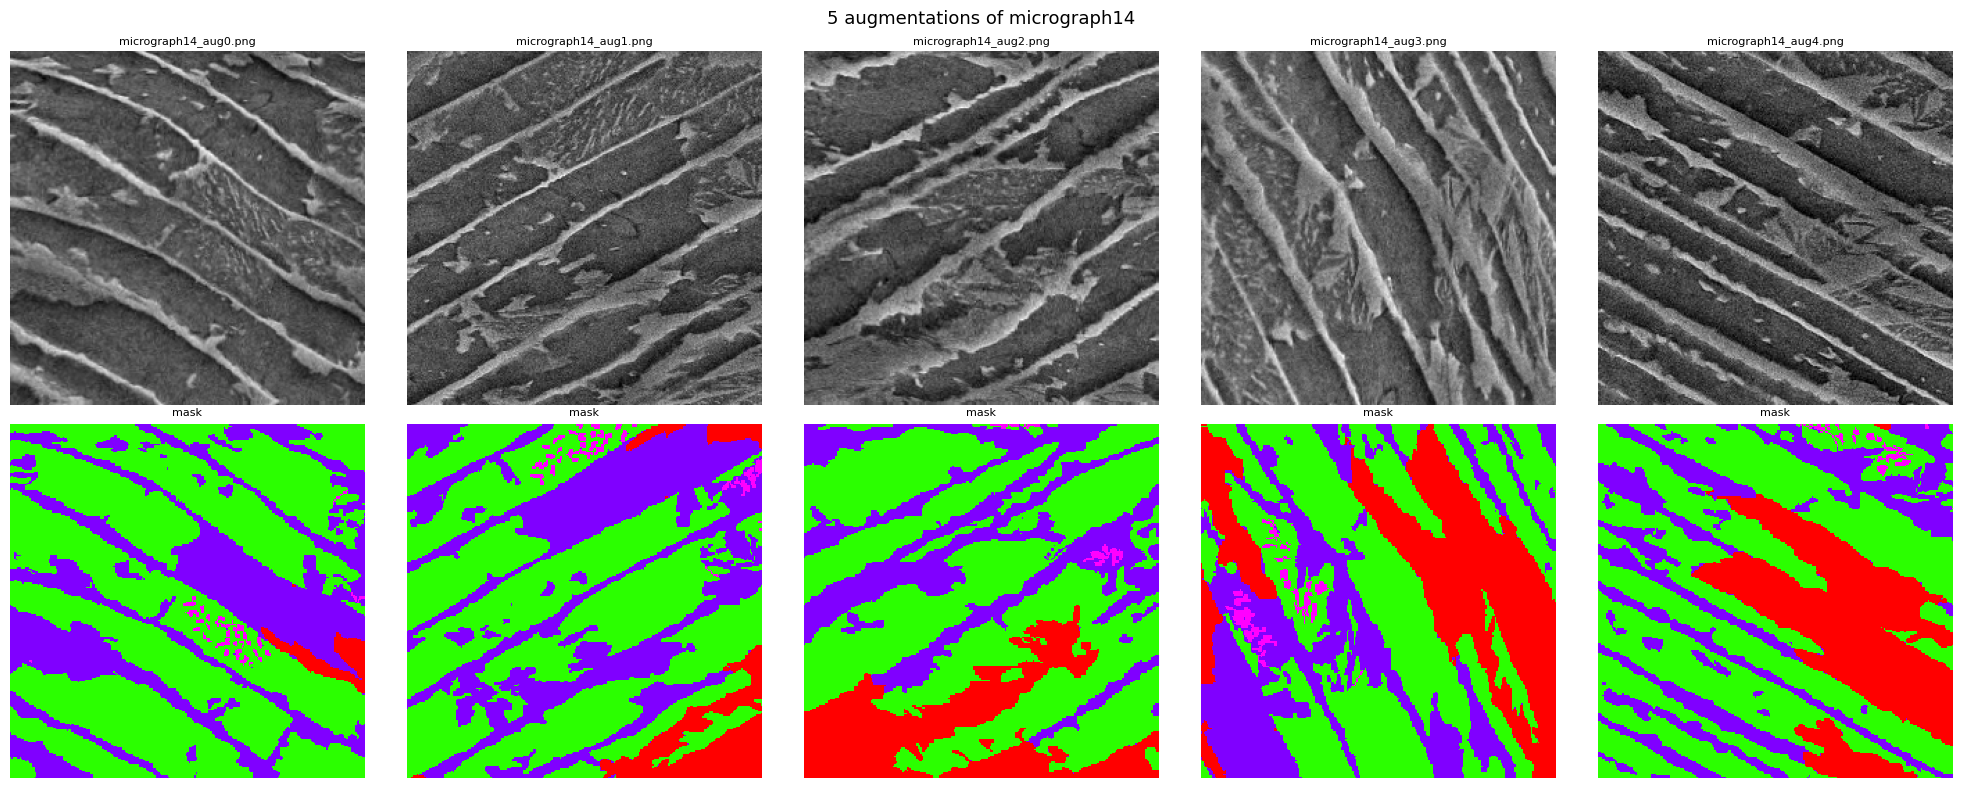

In [34]:
if __name__ == "__main__":
    print("Creating output directories…")
    create_output_dirs(TRAIN_IMG_DIR, TRAIN_MSK_DIR)

    print(f"\nAugmenting {len(train_pairs)} training pairs × {NUM_AUGMENTATIONS} = "
          f"{len(train_pairs) * NUM_AUGMENTATIONS} samples…")
    augment_and_save_pairs(
        train_pairs, TRAIN_IMG_DIR, TRAIN_MSK_DIR, train_transform, NUM_AUGMENTATIONS
    )

    # ── Sanity checks ──────────────────────────────────────────────────
    saved_imgs = sorted(TRAIN_IMG_DIR.glob("*.png"))
    saved_msks = sorted(TRAIN_MSK_DIR.glob("*.png"))
    print(f"\nSaved: {len(saved_imgs)} images, {len(saved_msks)} masks")

    # Show 5 augmented versions of one sample
    sample_stem = train_pairs[0][0].stem
    sample_files = sorted(TRAIN_IMG_DIR.glob(f"{sample_stem}_aug*.png"))

    fig, axes = plt.subplots(2, len(sample_files), figsize=(4 * len(sample_files), 8))
    for j, fpath in enumerate(sample_files):
        img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(str(TRAIN_MSK_DIR / fpath.name), cv2.IMREAD_UNCHANGED)

        axes[0, j].imshow(img, cmap="gray")
        axes[0, j].set_title(fpath.name, fontsize=8)
        axes[0, j].axis("off")

        if msk.ndim == 3:
            axes[1, j].imshow(cv2.cvtColor(msk, cv2.COLOR_BGR2RGB), interpolation="nearest")
        else:
            axes[1, j].imshow(msk, cmap=CLASS_CMAP, vmin=0, vmax=3, interpolation="nearest")
        axes[1, j].set_title("mask", fontsize=8)
        axes[1, j].axis("off")

    fig.suptitle(f"5 augmentations of {sample_stem}", fontsize=13)
    plt.tight_layout()
    plt.show()